## **Introduction**

Healthcare spending in the United States varies widely across hospitals, even for patients with similar medical needs. While some of this variation reflects differences in efficiency and practice patterns, much of it is driven by patient complexity, demographics, and regional cost factors. Comparing hospitals using raw cost metrics alone can therefore produce misleading conclusions and unfairly penalize institutions that serve sicker or more vulnerable populations.

In this project, I analyze Medicare inpatient hospital data to evaluate how patient risk and case mix influence hospital cost rankings. The goal is to estimate expected cost per discharge based on patient characteristics and to assess how hospital rankings change after adjusting for these factors. By comparing raw cost rankings with risk-adjusted rankings, this analysis highlights the importance of proper adjustment when evaluating provider performance and making network or referral decisions.




## **Data Overview**

This project uses publicly available 2023 Medicare Inpatient Hospital Public Use File (PUF) data released by the Centers for Medicare & Medicaid Services (CMS). The dataset contains hospital-level summaries of inpatient utilization, payments, and patient characteristics for Medicare fee-for-service beneficiaries.

Each row represents a hospital, identified by its CMS Certification Number (CCN), and includes aggregated counts of discharges, total Medicare payments, and covered inpatient days. The dataset also includes demographic distributions of beneficiaries by age, sex, race, and dual Medicare–Medicaid eligibility, as well as prevalence estimates for a wide range of chronic conditions derived from CMS Chronic Condition Warehouse (CCW) algorithms.

Key categories of variables include:

- **Utilization and Spending**
  - Total discharges
  - Total Medicare payment amount
  - Total covered days
  - Derived measures such as cost per discharge and average length of stay

- **Patient Demographics**
  - Average beneficiary age
  - Age group distributions
  - Sex and race composition
  - Dual eligibility status

- **Clinical Risk Indicators**
  - Average Hierarchical Condition Category (HCC) risk score
  - Prevalence of major chronic conditions (e.g., diabetes, heart failure, COPD, stroke)

- **Geographic Identifiers**
  - Hospital state and rural–urban commuting area (RUCA) classifications

Because the data are aggregated at the hospital level, individual patient trajectories and outcomes are not observed. However, the dataset provides a broad view of how patient complexity and population characteristics differ across hospitals and how these differences relate to spending patterns. A complete data dictionary will be attached with the data file.



## **Methodology**

This analysis uses the previously mentioned data to evaluate hospital cost performance while accounting for patient complexity and demographic composition. The primary outcome variable is Medicare cost per discharge, calculated as total Medicare payments divided by total inpatient discharges for each hospital.

To control for differences in patient severity, several risk-related features were incorporated into the model, including average HCC risk score, prevalence of chronic conditions, age distribution, and dual Medicare–Medicaid eligibility. Chronic disease prevalence variables were summarized using principal component analysis (PCA) to reduce dimensionality and capture overall comorbidity burden in a single composite index.

A log-linear ordinary least squares (OLS) regression model was then fit to estimate expected cost per discharge as a function of patient risk and demographic factors, along with state fixed effects to account for regional cost differences. Predicted values from the model represent expected spending given hospital case mix, while residuals capture deviation from expected cost.

Hospitals were ranked by both raw cost per discharge and residual cost, allowing comparison between unadjusted and risk-adjusted rankings. Rank changes were analyzed to assess how patient complexity influences performance comparisons.



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.formula.api as smf

In [ ]:
df = pd.read_csv("/content/Medicare_IP_Hospitals_by_Provider_2023.csv", encoding="latin1")

In [ ]:
print("Rows:", df.shape[0], "Cols:", df.shape[1])
print(df.head(3))

Rows: 3093 Cols: 57
   Rndrng_Prvdr_CCN                  Rndrng_Prvdr_Org_Name  \
0             10001        Southeast Health Medical Center   
1             10005  Marshall Medical Centers South Campus   
2             10006           North Alabama Medical Center   

              Rndrng_Prvdr_St Rndrng_Prvdr_City  Rndrng_Prvdr_Zip5  \
0      1108 Ross Clark Circle            Dothan              36301   
1  2505 U S Highway 431 North              Boaz              35957   
2         1701 Veterans Drive          Florence              35630   

  Rndrng_Prvdr_State_Abrvtn  Rndrng_Prvdr_State_FIPS  Rndrng_Prvdr_RUCA  \
0                        AL                        1                2.0   
1                        AL                        1                4.0   
2                        AL                        1                1.0   

                              Rndrng_Prvdr_RUCA_Desc  Tot_Benes  ...  \
0  Metropolitan area high commuting: primary flow...       3088  ...   
1  Mi

##  **Filtering Rows**


I will restrict analysis to hospitals with:

- At least 100 discharges
- At least 100 beneficiaries

This is to reduce the amount of high noise hospitals and hopefully give us a more reliable metric.


In [ ]:
MIN_DISCHARGES = 100
MIN_BENES = 100

df = df[(df["Tot_Dschrgs"] >= MIN_DISCHARGES) & (df["Tot_Benes"] >= MIN_BENES)].copy()

print("After filters:", df.shape)

After filters: (2887, 57)


##  **Feature Engineering**

Raw totals are not comparable across hospitals, so I would like to relative metrics instead of absolute ones.

I create the following simple metrics:

### Cost Metrics
- Medicare payment per discharge
- Total payment per discharge

### Utilization Metrics
- Average length of stay (LOS)
- Covered days per discharge

### Demographics
- Percent of beneficiaries over age 75
- Percent under age 65

### Socioeconomic Proxy
- Percent dual-eligible (Medicare + Medicaid)

These features help separate hospital efficiency from patient complexity.

In [ ]:
df["cost_per_discharge"] = df["Tot_Mdcr_Pymt_Amt"].astype(float) / df["Tot_Dschrgs"].astype(float)
df["total_payment_per_discharge"] = df["Tot_Pymt_Amt"].astype(float) / df["Tot_Dschrgs"].astype(float)

df["los"] = df["Tot_Days"].astype(float) / df["Tot_Dschrgs"].astype(float)
df["covered_days_per_discharge"] = df["Tot_Cvrd_Days"].astype(float) / df["Tot_Dschrgs"].astype(float)

df["pct_under_65"] = df["Bene_Age_LT_65_Cnt"] / df["Tot_Benes"]
df["pct_over_75"] = (df["Bene_Age_75_84_Cnt"] + df["Bene_Age_GT_84_Cnt"]) / df["Tot_Benes"]

df["dual_pct"] = df["Bene_Dual_Cnt"] / df["Tot_Benes"]

## **Chronic Condition PCA**

As many medical professionals know, patients often have multiple overlapping chronic diseases which can be highly correlated with each other.

Instead of evaluating many correlated condition variables independently, I'll create a single index using the following common conditions:

- Diabetes
- COPD
- Chronic kidney disease
- Heart failure
- Stroke/TIA
- Cancer

I will use Principal Component Analysis to compress these into one composite score that (hopefully) captures overall disease severity while avoiding multicollinearity.

In [ ]:
chronic_cols = [
    "Bene_CC_PH_Diabetes_V2_Pct",
    "Bene_CC_PH_COPD_V2_Pct",
    "Bene_CC_PH_CKD_V2_Pct",
    "Bene_CC_PH_HF_NonIHD_V2_Pct",
    "Bene_CC_PH_Stroke_TIA_V2_Pct",

]
scaler = StandardScaler()
X = scaler.fit_transform(df[chronic_cols])

pca = PCA(n_components=1)
df["chronic_burden_pca1"] = pca.fit_transform(X).ravel()

print("PCA variance explained:", pca.explained_variance_ratio_)

PCA variance explained: [0.59015123]


In [ ]:
pd.Series(pca.components_[0], index=chronic_cols).sort_values(ascending=False)

,0
Bene_CC_PH_HF_NonIHD_V2_Pct,0.515764
Bene_CC_PH_CKD_V2_Pct,0.480276
Bene_CC_PH_Diabetes_V2_Pct,0.466500
Bene_CC_PH_COPD_V2_Pct,0.384824
Bene_CC_PH_Stroke_TIA_V2_Pct,0.370959


After inspecting the PCA loadings, I found that cancer prevalence did not align with the dominant comorbidity pattern captured by the first principal component.

Therefore, I excluded cancer prevalence from the PCA and  will model it as a separate covariate in the risk adjustment model.

This refinement increased the variance explained by the first principal component from approximately 50% to nearly 60%, indicating a more coherent and clinically interpretable measure of general chronic disease burden.

### Raw Cost vs Patient Risk (Before Risk Adjustment)

Before applying any adjustment, I would like to examine the relationship between hospital cost per discharge and average patient risk score.

This will answer two questions:
- Does cost generally increase as patient risk increases?
- How much variation exists among hospitals treating similarly risky patients?




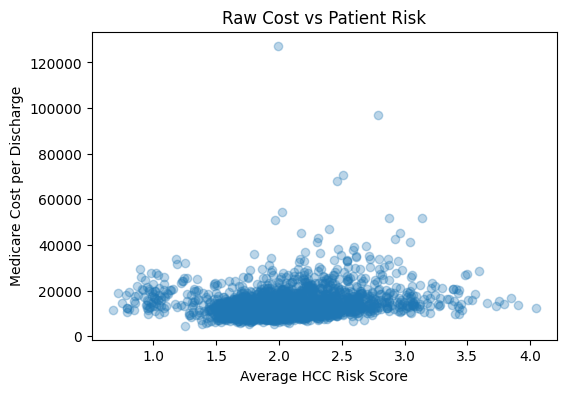

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Bene_Avg_Risk_Scre"], df["cost_per_discharge"], alpha=0.3)
plt.xlabel("Average HCC Risk Score")
plt.ylabel("Medicare Cost per Discharge")
plt.title("Raw Cost vs Patient Risk")
plt.show()


This scatterplot shows a weak relationship between patient risk and Medicare cost per discharge, with substantial variation among hospitals at nearly every risk level. It seems likely inpatient costs are driven not only by chronic illness but also by procedures, ICU use, and hospital pricing practices.




### **Risk Adjustment Model**

To estimate how much each hospital *should* cost given its patient population, I will attempt to fit a regression model predicting cost per discharge from patient complexity and demographic factors.

Because healthcare cost data is highly right-skewed and influenced by extreme outliers, I model the **log of cost per discharge** rather than raw cost. This improves model stability and ensures that prediction errors are interpreted in relative (percentage) rather than absolute dollar terms.

The model includes the following adjustment variables:
- **Average HCC risk score** to capture diagnosis-based severity
- **Composite chronic disease burden (PCA)** to summarize correlated comorbidities
- **Cancer Prevalence** — percent of beneficiaries with one of six major cancers.
- **Percent of patients over age 75** to account for frailty
- **Percent dual-eligible** as a proxy for socioeconomic complexity
- **State fixed effects** to control for geographic price differences

Together, these features should help estimate the expected cost attributable to other factors, rather than hospital efficiency exclusively.


In [ ]:
EPS = 1e-6
df["log_cost_per_discharge"] = np.log(df["cost_per_discharge"] + EPS)

formula = """
log_cost_per_discharge
~ Bene_Avg_Risk_Scre
+ chronic_burden_pca1
+ Bene_CC_PH_Cancer6_V2_Pct
+ pct_over_75
+ dual_pct
+ C(Rndrng_Prvdr_State_Abrvtn)
"""
model_df = df.dropna(subset=[
    "log_cost_per_discharge",
    "Bene_Avg_Risk_Scre",
    "chronic_burden_pca1",
    "Bene_CC_PH_Cancer6_V2_Pct",
    "pct_over_75",
    "dual_pct"
]).copy()

ols = smf.ols(formula=formula, data=model_df).fit()
print(ols.summary())

                              OLS Regression Results                              
Dep. Variable:     log_cost_per_discharge   R-squared:                       0.477
Model:                                OLS   Adj. R-squared:                  0.467
Method:                     Least Squares   F-statistic:                     45.16
Date:                    Tue, 27 Jan 2026   Prob (F-statistic):               0.00
Time:                            03:24:19   Log-Likelihood:                 52.255
No. Observations:                    2775   AIC:                             7.490
Df Residuals:                        2719   BIC:                             339.5
Df Model:                              55                                         
Covariance Type:                nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

### **Interpretation of Model Coefficients**

Several variables show strong and statistically significant associations with inpatient cost per discharge:

- **Average HCC Risk Score** has a positive and highly significant coefficient, indicating that hospitals treating more medically complex patients are expected to have higher costs per discharge, as expected.

- **Cancer Prevalence** shows a large positive effect, reflecting the high resource intensity of oncology-related admissions and specialized inpatient services.

- **Percent of Patients Over Age 75** is also strongly associated with higher costs, capturing increased frailty and care intensity among the oldest beneficiaries.

The composite **chronic disease burden index** has a small negative coefficient after controlling for HCC risk, suggesting it captures stable chronic illness patterns that are less costly per admission than acute, high-intensity cases once diagnosis-based severity is accounted for.

**Dual eligibility** does not show a statistically significant independent effect after adjusting for medical complexity and geography, indicating that its contribution to inpatient cost is largely mediated through other patient characteristics already included in the model.

In [ ]:
model_df["pred_log_cost"] = ols.predict(model_df)
model_df["expected_cost"] = np.exp(model_df["pred_log_cost"])
model_df["residual_cost"] = model_df["cost_per_discharge"] - model_df["expected_cost"]

### **Estimating Expected Cost and Risk-Adjusted Performance**

Using the fitted regression model, I estimate the expected cost per discharge for each hospital based on its patient mix and geographic location. Predictions are generated on the log scale and then exponentiated to return to dollar units.

Hospital performance is evaluated using the difference between observed and expected cost:

 **Residual Cost = Actual Cost − Expected Cost**

This residual represents how much more or less a hospital spends compared to what would be expected for a similar patient population. Negative residuals indicate lower-than-expected cost (good performance), while positive residuals indicate higher-than-expected cost (bad performance)
.

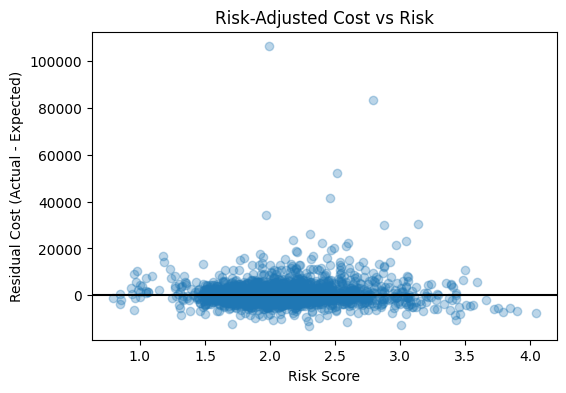

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(model_df["Bene_Avg_Risk_Scre"], model_df["residual_cost"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Risk Score")
plt.ylabel("Residual Cost (Actual - Expected)")
plt.title("Risk-Adjusted Cost vs Risk")
plt.show()

### **Residual Cost vs Risk Score**

After risk adjustment, residual cost should not exhibit a strong relationship with patient risk. A flat pattern around zero indicates that the model has successfully accounted for differences in patient complexity across hospitals.

The scatterplot shows that residuals are largely centered around zero across the full range of risk scores, suggesting that higher-risk hospitals are no longer systematically classified as more expensive after adjustment. Remaining variation reflects hospital-specific cost differences rather than differences in patient severity.




### **Comparing Hospital Rankings Before and After Risk Adjustment**

To evaluate how much patient risk adjustment changes hospital performance comparisons, I will compute two rankings:

- **Raw Cost Rank** — hospitals ranked by observed Medicare cost per discharge (lower is better).
- **Risk-Adjusted Rank** — hospitals ranked by residual cost after accounting for patient mix and geography(low residual cost -> better rank).

Plotting these rankings against each other allows us to assess:
- How similar raw and adjusted rankings are overall
- Whether certain hospitals move substantially after accounting for patient complexity



In [ ]:
# Raw cost rank (lower cost = better rank)
model_df["raw_rank"] = model_df["cost_per_discharge"].rank(ascending=True)

# Risk-adjusted rank (lower residual = better rank)
model_df["adjusted_rank"] = model_df["residual_cost"].rank(ascending=True)

# Rank change: positive = moved up after adjustment
model_df["rank_change"] = model_df["raw_rank"] - model_df["adjusted_rank"]

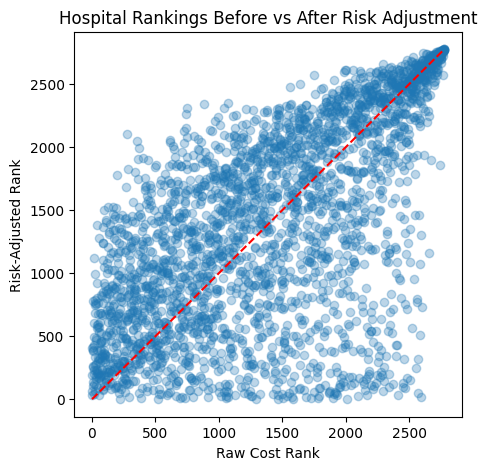

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(model_df["raw_rank"], model_df["adjusted_rank"], alpha=0.3)
plt.plot([1, len(model_df)], [1, len(model_df)], color="red", linestyle="--")
plt.xlabel("Raw Cost Rank")
plt.ylabel("Risk-Adjusted Rank")
plt.title("Hospital Rankings Before vs After Risk Adjustment")
plt.show()

### **Interpretation**

Points along the diagonal represent hospitals whose rankings change little after adjustment, while points far from the diagonal indicate large rank shifts.

Most hospitals fall near the diagonal line, indicating that raw and risk-adjusted rankings may be broadly correlated. However, there is substantial dispersion far from the diagonal, indicating that many hospitals experience meaningful rank changes after accounting for patient complexity.

Hospitals above the diagonal have worse raw rankings than risk-adjusted rankings, meaning they appear more expensive before adjustment but perform better once patient risk is considered. Conversely, hospitals below the diagonal appear relatively inexpensive on raw cost but move downward after adjustment, suggesting that lower observed costs may be partly driven by treating less complex patients.

This dispersion highlights the importance of risk adjustment for fair provider comparisons, as relying solely on raw cost can misrepresent hospital performance for institutions serving higher-risk populations.

We can similarly graph the distribution of rank changes to visualize the impact the adjusted risk score has on ranking hospitals:


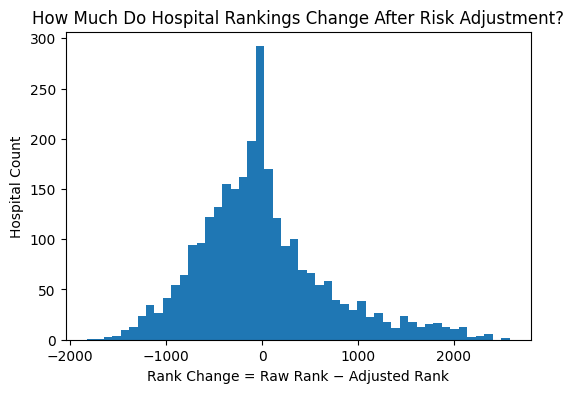

In [ ]:

plt.figure(figsize=(6,4))
plt.hist(model_df["rank_change"].dropna(), bins=50)
plt.xlabel("Rank Change = Raw Rank − Adjusted Rank")
plt.ylabel("Hospital Count")
plt.title("How Much Do Hospital Rankings Change After Risk Adjustment?")
plt.show()

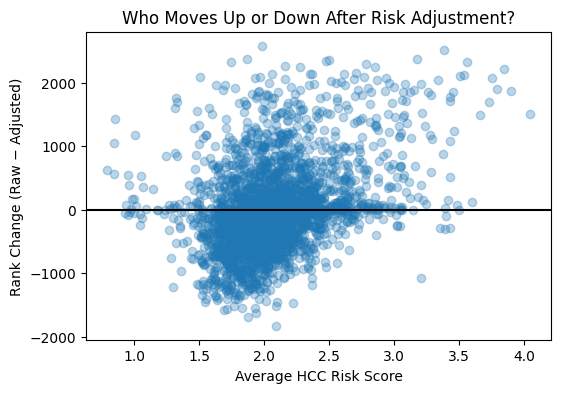

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(model_df["Bene_Avg_Risk_Scre"], model_df["rank_change"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Average HCC Risk Score")
plt.ylabel("Rank Change (Raw − Adjusted)")
plt.title("Who Moves Up or Down After Risk Adjustment?")
plt.show()




This plot shows a positive relationship between patient risk and ranking improvement after adjustment. Hospitals serving higher-risk populations tend to move up in ranking once patient complexity is accounted for, while hospitals serving lower-risk populations often move down.

This pattern indicates that raw cost rankings are biased by patient mix. Risk adjustment corrects for this by separating true cost performance from the underlying health of the patient population. However, the wide spread of rank changes at each risk level suggests that patient severity alone may not fully explain cost differences.

### **Hospitals Most Affected by Risk Adjustment**

To examine which institutions are most impacted by risk adjustment, I will look at hospitals with the largest ranking changes between raw cost rankings and risk-adjusted rankings.

Two groups are highlighted:
- Hospitals that **improve the most** after adjustment (suggesting they treat sicker patients than average)
- Hospitals that **drop the most** after adjustment (suggesting lower patient complexity may partially explain low observed costs)



In [ ]:


cols = [
    "Rndrng_Prvdr_Org_Name",
    "Rndrng_Prvdr_City",
    "Rndrng_Prvdr_State_Abrvtn",
    "Tot_Dschrgs",
    "Bene_Avg_Risk_Scre",
    "cost_per_discharge",
    "expected_cost",
    "residual_cost",
    "raw_rank",
    "adjusted_rank",
    "rank_change"
]

print("\nTop 10 hospitals that IMPROVE most after adjustment:")
display(model_df.sort_values("rank_change", ascending=False)[cols].head(10))

print("\nTop 10 hospitals that DROP most after adjustment:")
display(model_df.sort_values("rank_change", ascending=True)[cols].head(10))


Top 10 hospitals that IMPROVE most after adjustment (move up):


,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Tot_Dschrgs,Bene_Avg_Risk_Scre,cost_per_discharge,expected_cost,residual_cost,raw_rank,adjusted_rank,rank_change
1301,Mercy Medical Center Inc,Baltimore,MD,2327,1.985184,21552.183498,29951.329521,-8399.146023,2595.0,15.0,2580.0
468,"Martin Luther King, Jr. Community Hospital",Los Angeles,CA,1051,3.387615,20880.427212,26988.076987,-6107.649774,2568.0,54.0,2514.0
238,Community Hospital Of San Bernardino,San Bernardino,CA,390,3.177760,18007.548718,24908.347168,-6900.798450,2407.0,34.0,2373.0
252,San Mateo Medical Center,San Mateo,CA,197,1.867048,18772.964467,23844.881791,-5071.917324,2462.0,90.0,2372.0
1324,Northwest Hospital Center,Randallstown,MD,3161,2.499916,18650.383107,23557.187209,-4906.804103,2452.0,100.0,2352.0
424,"Kaiser Foundation Hospital, Riverside",Riverside,CA,376,2.476126,19387.582447,23356.357769,-3968.775322,2502.0,157.0,2345.0
247,Saint Francis Medical Center,Lynwood,CA,1793,3.562478,18586.884551,22881.876873,-4294.992322,2448.0,131.0,2317.0
84,Alaska Regional Hospital,Anchorage,AK,2981,1.748103,19052.684670,22893.753758,-3841.069088,2485.0,169.0,2316.0
1330,Medstar Good Samaritan Hospital,Baltimore,MD,4058,2.785499,20475.609660,23782.870576,-3307.260916,2552.0,252.0,2300.0
139,Banner Gateway Medical Center,Gilbert,AZ,1845,2.162613,17478.079675,22017.596702,-4539.517027,2372.0,119.0,2253.0



Top 10 hospitals that DROP most after adjustment (move down):


,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Tot_Dschrgs,Bene_Avg_Risk_Scre,cost_per_discharge,expected_cost,residual_cost,raw_rank,adjusted_rank,rank_change
1219,Ochsner American Legion Hospital,Jennings,LA,577,2.089305,8802.564991,7067.724744,1734.840247,277.0,2104.0,-1827.0
1163,Logan Memorial Hospital,Russellville,KY,145,1.873232,9110.337931,7543.138526,1567.199405,353.0,2049.0,-1696.0
3,Mizell Memorial Hospital,Opp,AL,353,1.935085,9199.203966,7821.730502,1377.473464,369.0,1992.0,-1623.0
1060,Mercyone Newton Medical Center,Newton,IA,271,1.694606,8425.601476,7632.613398,792.988078,197.0,1779.0,-1582.0
2521,Lincoln Medical Center,Fayetteville,TN,266,1.712643,10251.793233,7540.017462,2711.775771,746.0,2313.0,-1567.0
31,Highlands Medical Center,Scottsboro,AL,522,1.827145,9176.727969,8034.700440,1142.027529,364.0,1907.0,-1543.0
2541,Southern Tennessee Regional Health System Lawr...,Lawrenceburg,TN,491,1.933380,8810.209776,7913.356959,896.852817,281.0,1823.0,-1542.0
2535,Ascension Saint Thomas River Park Hospital,Mcminnville,TN,574,1.766177,10228.188153,7794.451572,2433.736581,739.0,2263.0,-1524.0
33,Russell Medical Center,Alexander City,AL,393,2.094663,9296.966921,8147.991634,1148.975287,401.0,1911.0,-1510.0
1240,Franklin Medical Center,Winnsboro,LA,273,2.222140,10592.923077,7716.580053,2876.343024,881.0,2343.0,-1462.0



Hospitals that improve the most after adjustment generally have higher average patient risk scores and large negative residual costs, indicating they spend less than expected given the severity of their patient populations. These hospitals may appear expensive on raw cost alone but perform relatively efficiently once case complexity is considered.

Conversely, hospitals that drop the most after adjustment tend to serve lower-risk populations and have positive residual costs, meaning their observed spending is higher than expected given patient severity. This suggests that some institutions benefiting from low raw cost rankings may be advantaged by treating less complex patients rather than by superior efficiency alone.

These findings reinforce the importance of risk adjustment when comparing providers, as raw cost metrics can misrepresent performance for hospitals serving more medically complex populations.


### **Best and Worst Performing Hospitals After Risk Adjustment**

To complete the analysis, I'll graph the top 5 and bottom 5 ranked hospital after risk adjustment to see some examples of hospitals that are financially efficient and have much lower costs than expected, and hospitals that are very inefficient and have much higher costs than expected.



In [ ]:
top5 = model_df.sort_values("adjusted_rank", ascending=True)[cols].head(5)
print("Top 5 Hospitals by Risk-Adjusted Cost (Best Value):")
display(top5)

Top 5 Hospitals by Risk-Adjusted Cost (Best Value):


,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Tot_Dschrgs,Bene_Avg_Risk_Scre,cost_per_discharge,expected_cost,residual_cost,raw_rank,adjusted_rank,rank_change
269,Kaiser Foundation Hospital - Panorama City,Panorama City,CA,416,2.301655,12617.987981,25626.946026,-13008.958045,1587.0,1.0,1586.0
309,Good Samaritan Hospital,Bakersfield,CA,393,3.007987,12225.002545,24943.338159,-12718.335615,1465.0,2.0,1463.0
833,Kaiser Foundation Hospital,Honolulu,HI,688,1.710483,11690.680233,23879.806518,-12189.126286,1294.0,3.0,1291.0
350,Pacifica Hospital Of The Valley,Sun Valley,CA,348,2.589177,14462.362069,25979.811166,-11517.449097,2006.0,4.0,2002.0
1925,Clifton Springs Hospital And Clinic,Clifton Springs,NY,413,2.291439,8573.232446,19530.892631,-10957.660186,222.0,5.0,217.0


The hospitals above represent the strongest cost performance after adjusting for patient risk and case mix. These institutions spend substantially less than expected for comparable patients, suggesting relatively efficient care delivery under this model. It's worth noting that of these 5, their new adjusted rank is a considerable improvement from where the raw rank placed them.


In contrast, the hospitals below show the largest positive residual costs, indicating spending that is much higher than predicted given patient characteristics. Additionally, unlike the top 5 which were previously ranked much differently, the bottom 5 have almost no movement at all and have a similar rank to their raw rank.



In [ ]:
bottom5 = model_df.sort_values("adjusted_rank", ascending=False)[cols].head(5)
print("Bottom 5 Hospitals by Risk-Adjusted Cost (Worst Value):")
display(bottom5)

Bottom 5 Hospitals by Risk-Adjusted Cost (Worst Value):


,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Tot_Dschrgs,Bene_Avg_Risk_Scre,cost_per_discharge,expected_cost,residual_cost,raw_rank,adjusted_rank,rank_change
2638,Harris Health System,Houston,TX,1087,1.992596,127333.767249,20668.490762,106665.276487,2775.0,2775.0,0.0
969,Provident Hospital Of Chicago,Chicago,IL,132,2.791481,96930.318182,13509.491438,83420.826744,2774.0,2774.0,0.0
905,John H Stroger Jr Hospital,Chicago,IL,1234,2.512596,70549.355754,18182.071461,52367.284293,2773.0,2773.0,0.0
1296,University Of Maryland Medical Center,Baltimore,MD,6421,2.461048,67992.853761,26242.753927,41750.099834,2772.0,2772.0,0.0
1337,Levindale Hebrew Geriatric Center And Hospital,Baltimore,MD,686,1.966689,50958.241983,16694.456333,34263.785649,2769.0,2771.0,-2.0


## **Limitations**

Several limitations should be considered when interpreting these results. Firstly, this analysis relies on aggregated hospital-level data rather than patient-level claims, which limits the precision of risk adjustment and prevents modeling individual results

Additionally, the study focuses exclusively on cost outcomes and does not incorporate measures of clinical quality such as mortality, readmissions, complications, or patient experience. As a result, hospitals with low costs are not necessarily delivering higher-quality care, and cost efficiency should not be interpreted as overall performance.

Nevertheless, the magnitude of the differences observed here underscores how misleading raw cost comparisons can be and illustrates the practical importance of risk adjustment in provider evaluation and network design.



## **Conclusion**

This analysis demonstrates that patient risk and case mix substantially influence hospital cost comparisons and that risk adjustment meaningfully reshapes provider rankings. Hospitals serving more medically complex populations tend to appear more expensive in raw cost rankings but often improve substantially after adjusting for patient severity. Conversely, some hospitals with low raw costs move downward once differences in case mix are accounted for.

By modeling expected cost per discharge using patient demographics, chronic condition prevalence, and HCC risk scores, this project highlights how residual-based performance measures can provide a fairer assessment of hospital spending behavior. The observed rank shifts and value tier changes suggest that unadjusted cost metrics may misrepresent provider performance and could lead to biased network design or referral recommendations.

Although this study focuses exclusively on cost outcomes and uses aggregated hospital-level data, the results underscore the importance of incorporating patient complexity into provider evaluation frameworks. In real-world applications, combining risk-adjusted cost measures with quality and outcome metrics would provide a more complete view of provider value and support more equitable, data-driven healthcare decision-making.
